In [ ]:
# ==============================================================
# 📥 STEP 1: DOWNLOAD & SPLIT (80% Train / 10% Val / 10% Test)
# ==============================================================
!pip install -q kagglehub

import os
import shutil
import glob
import random
import kagglehub
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Download Dataset
print("[1/3] Downloading ndisan/corn-leaf-disease...")
raw_path = kagglehub.dataset_download("ndisan/corn-leaf-disease")

# 2. Setup 80/10/10 Target Directories
TARGET_DIR = "/content/corn_field_dataset"
CLASS_MAPPING = {
    'hawar': 'Blight',          # Hawar Daun
    'karat': 'Common_Rust',     # Karat Daun
    'bercak': 'Gray_Leaf_Spot',  # Bercak Daun
    'sehat': 'Healthy'          # Daun Sehat
}

# Clean existing directory if any
if os.path.exists(TARGET_DIR):
    shutil.rmtree(TARGET_DIR)

for split in ['train', 'val', 'test']:
    for cls in ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']:
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)

# 3. 80/10/10 Splitting Logic
print("[2/3] Splitting into 80% Train, 10% Val, 10% Test...")

for root, dirs, files in os.walk(raw_path):
    for d in dirs:
        d_lower = d.lower()
        matched_class = None
        for key, target_name in CLASS_MAPPING.items():
            if key in d_lower:
                matched_class = target_name
                break

        if matched_class:
            src_folder = os.path.join(root, d)
            images = glob.glob(os.path.join(src_folder, "*.*"))
            random.seed(42)
            random.shuffle(images)

            n = len(images)
            train_idx = int(0.80 * n)
            val_idx = int(0.90 * n)

            train_imgs = images[:train_idx]         # 80%
            val_imgs = images[train_idx:val_idx]     # 10%
            test_imgs = images[val_idx:]            # 10%

            for img in train_imgs:
                shutil.copy(img, os.path.join(TARGET_DIR, 'train', matched_class))
            for img in val_imgs:
                shutil.copy(img, os.path.join(TARGET_DIR, 'val', matched_class))
            for img in test_imgs:
                shutil.copy(img, os.path.join(TARGET_DIR, 'test', matched_class))

# 4. Summary Verification
print("\n" + "="*55)
print("📊 80/10/10 DATASET SUMMARY:")
print("="*55)
for split in ['train', 'val', 'test']:
    print(f"\n📁 [{split.upper()} SET]:")
    total_split = 0
    for cls in ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']:
        count = len(os.listdir(os.path.join(TARGET_DIR, split, cls)))
        total_split += count
        print(f"  - {cls:<18}: {count} images")
    print(f"  Total: {total_split} images")
print("="*55)

[1/3] Downloading ndisan/corn-leaf-disease...


100%|██████████| 5.11G/5.11G [00:56<00:00, 97.1MB/s]

Extracting files...


[2/3] Splitting into 80% Train, 10% Val, 10% Test...

📊 80/10/10 DATASET SUMMARY:

📁 [TRAIN SET]:
  - Blight            : 800 images
  - Common_Rust       : 800 images
  - Gray_Leaf_Spot    : 800 images
  - Healthy           : 800 images
  Total: 3200 images

📁 [VAL SET]:
  - Blight            : 100 images
  - Common_Rust       : 100 images
  - Gray_Leaf_Spot    : 100 images
  - Healthy           : 100 images
  Total: 400 images

📁 [TEST SET]:
  - Blight            : 100 images
  - Common_Rust       : 100 images
  - Gray_Leaf_Spot    : 100 images
  - Healthy           : 100 images
  Total: 400 images


In [ ]:
# ==============================================================
# 💾 SAVE TEST DATASET & FULL BACKUP TO GOOGLE DRIVE
# ==============================================================
import os
import shutil
from google.colab import drive

# 1. Ensure Drive is mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/Corn_Disease_Project"
DRIVE_DATASET_DIR = os.path.join(DRIVE_PROJECT_DIR, "dataset")
DRIVE_TEST_DIR = os.path.join(DRIVE_DATASET_DIR, "test")
os.makedirs(DRIVE_DATASET_DIR, exist_ok=True)

# 2. Copy Test Split to Google Drive
SOURCE_TEST_DIR = "/content/corn_field_dataset/test"

if os.path.exists(DRIVE_TEST_DIR):
    shutil.rmtree(DRIVE_TEST_DIR)

print("[1/2] Saving test split to Google Drive...")
shutil.copytree(SOURCE_TEST_DIR, DRIVE_TEST_DIR)

# 3. Create Full Dataset Backup Zip on Drive (Future use ke liye)
print("[2/2] Creating complete dataset backup zip on Drive...")
shutil.make_archive(os.path.join(DRIVE_PROJECT_DIR, "corn_field_dataset_backup"), 'zip', "/content/corn_field_dataset")

# 4. Verify & Summary
print("\n" + "="*55)
print("✅ TEST DATASET SAVED SUCCESSFULLY TO GOOGLE DRIVE:")
print("="*55)
print(f"📁 Path: {DRIVE_TEST_DIR}\n")
total_test = 0
for cls in sorted(os.listdir(DRIVE_TEST_DIR)):
    cls_path = os.path.join(DRIVE_TEST_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_test += count
        print(f"  - {cls:<18}: {count} images")
print("-"*55)
print(f"Total Test Images: {total_test}")
print("="*55)

Mounted at /content/drive
[1/2] Saving test split to Google Drive...
[2/2] Creating complete dataset backup zip on Drive...

✅ TEST DATASET SAVED SUCCESSFULLY TO GOOGLE DRIVE:
📁 Path: /content/drive/MyDrive/Corn_Disease_Project/dataset/test

  - Blight            : 100 images
  - Common_Rust       : 100 images
  - Gray_Leaf_Spot    : 100 images
  - Healthy           : 100 images
-------------------------------------------------------
Total Test Images: 400


In [ ]:
# ==============================================================
# ⚡ FAST & FAILURE-PROOF TRAINING (INSTANT AUTO-SAVE TO DRIVE)
# ==============================================================
import os
import shutil
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/Corn_Disease_Project"
MODEL_SAVE_PATH = os.path.join(DRIVE_DIR, "best_hybrid_corn_model_clean.pth")
DATASET_LOCAL = "/content/corn_field_dataset"

# 2. Extract Dataset to Local SSD in 5 Seconds
if not os.path.exists(DATASET_LOCAL):
    BACKUP_ZIP = os.path.join(DRIVE_DIR, "corn_field_dataset_backup.zip")
    if os.path.exists(BACKUP_ZIP):
        print("[1/3] Extracting dataset from Drive backup...")
        shutil.unpack_archive(BACKUP_ZIP, DATASET_LOCAL)
    else:
        print("[1/3] Downloading fresh dataset via kagglehub...")
        import kagglehub
        raw_path = kagglehub.dataset_download("ndisan/corn-leaf-disease")
        # Split setup
        CLASS_MAPPING = {'hawar': 'Blight', 'karat': 'Common_Rust', 'bercak': 'Gray_Leaf_Spot', 'sehat': 'Healthy'}
        for split in ['train', 'val', 'test']:
            for cls in ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']:
                os.makedirs(os.path.join(DATASET_LOCAL, split, cls), exist_ok=True)
        for root, dirs, files in os.walk(raw_path):
            for d in dirs:
                for key, target_name in CLASS_MAPPING.items():
                    if key in d.lower():
                        images = glob.glob(os.path.join(root, d, "*.*"))
                        random.seed(42); random.shuffle(images)
                        n = len(images)
                        for img in images[:int(0.8*n)]: shutil.copy(img, os.path.join(DATASET_LOCAL, 'train', target_name))
                        for img in images[int(0.8*n):int(0.9*n)]: shutil.copy(img, os.path.join(DATASET_LOCAL, 'val', target_name))
                        for img in images[int(0.9*n):]: shutil.copy(img, os.path.join(DATASET_LOCAL, 'test', target_name))

print("[INFO] Dataset ready on high-speed disk.")

# 3. Device & Transforms
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2))
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. DataLoaders
train_dataset = datasets.ImageFolder(os.path.join(DATASET_LOCAL, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_LOCAL, 'val'), transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 5. Hybrid Architecture
class HybridCornNet(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(HybridCornNet, self).__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.cnn = models.efficientnet_b0(weights=weights)
        self.cnn.classifier = nn.Identity()
        self.vit = timm.create_model('deit_tiny_patch16_224', pretrained=pretrained)
        self.vit.head = nn.Identity()
        self.fusion_head = nn.Sequential(
            nn.Linear(1280 + 192, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat_maps = self.cnn.features(x)
        feat_cnn = self.cnn.avgpool(feat_maps).flatten(1)
        feat_vit = self.vit(x)
        fused = torch.cat((feat_cnn, feat_vit), dim=1)
        return self.fusion_head(fused)

model = HybridCornNet(num_classes=4, pretrained=True).to(DEVICE)

# 6. Training Configuration (10 Epochs is optimal)
EPOCHS = 10
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0

print("\n" + "="*65)
print("🚀 STARTING FAST ANTI-BIAS TRAINING (10 EPOCHS)")
print("="*65)

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    scheduler.step()
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (running_corrects.double() / total_train).item() * 100

    model.eval()
    val_loss, val_corrects, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (val_corrects.double() / total_val).item() * 100
    time_elapsed = time.time() - start_time

    # 💾 HAR EPOCH PAR BEST WEIGHTS FORAN GOOGLE DRIVE MEIN SAVE HONGI
    saved_flag = ""
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved_flag = "⭐ [SAVED TO DRIVE]"

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({time_elapsed:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.2f}% {saved_flag}")

print("\n" + "="*65)
print(f"🏆 TRAINING COMPLETE! Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"💾 Model Weights Permanently Saved on Drive: {MODEL_SAVE_PATH}")
print("="*65)

[1/3] Extracting dataset from Drive backup...
[INFO] Dataset ready on high-speed disk.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 111MB/s] 


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            


🚀 STARTING FAST ANTI-BIAS TRAINING (10 EPOCHS)
Epoch [01/10] (421.9s) | Train Loss: 0.5450 - Acc: 91.19% | Val Loss: 0.4333 - Acc: 97.00% ⭐ [SAVED TO DRIVE]
Epoch [02/10] (399.2s) | Train Loss: 0.4692 - Acc: 95.28% | Val Loss: 0.4267 - Acc: 96.75% 
Epoch [03/10] (391.7s) | Train Loss: 0.4413 - Acc: 96.53% | Val Loss: 0.4300 - Acc: 95.75% 
Epoch [04/10] (398.4s) | Train Loss: 0.4321 - Acc: 96.75% | Val Loss: 0.4181 - Acc: 96.75% 
Epoch [05/10] (392.5s) | Train Loss: 0.4221 - Acc: 97.53% | Val Loss: 0.4058 - Acc: 97.50% ⭐ [SAVED TO DRIVE]
Epoch [06/10] (386.6s) | Train Loss: 0.4100 - Acc: 98.03% | Val Loss: 0.4120 - Acc: 97.25% 
Epoch [07/10] (381.6s) | Train Loss: 0.4078 - Acc: 97.84% | Val Loss: 0.4035 - Acc: 98.00% ⭐ [SAVED TO DRIVE]
Epoch [08/10] (384.0s) | Train Loss: 0.3966 - Acc: 98.19% | Val Loss: 0.3912 - Acc: 98.50% ⭐ [SAVED TO DRIVE]
Epoch [09/10] (397.3s) | Train Loss: 0.3934 - Acc: 98.66% | Val Loss: 0.3877 - Acc: 98.50% 
Epoch [10/10] (390.3s) | Train Loss: 0.3909 - Acc: 9

[1/2] Generating Pathology Grad-CAM Attention Figures...


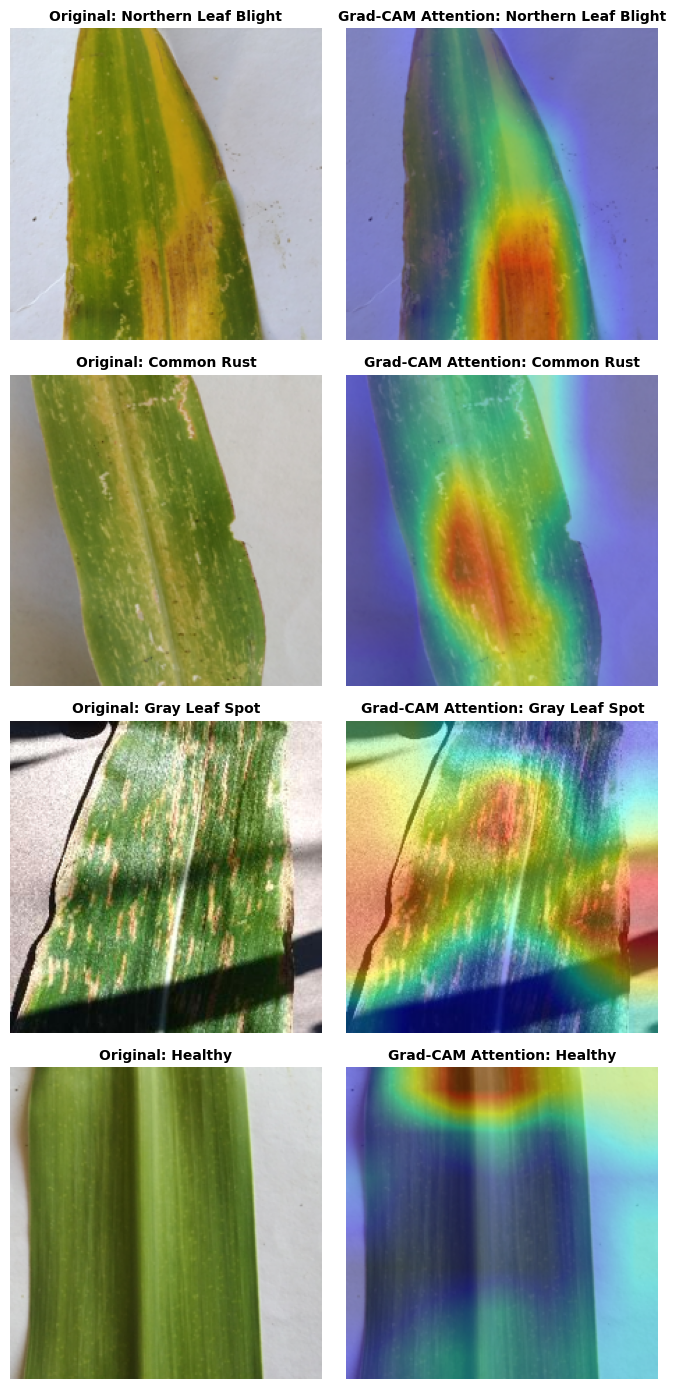

✅ Saved: /content/drive/MyDrive/Corn_Disease_Project/new images/pathology_gradcam.jpg

[2/2] Generating Classification Report...

📑 FINAL TEST CLASSIFICATION REPORT (OVERALL ACCURACY: 98.75%)
                      precision    recall  f1-score   support

Northern Leaf Blight     0.9709    1.0000    0.9852       100
         Common Rust     0.9798    0.9700    0.9749       100
      Gray Leaf Spot     1.0000    1.0000    1.0000       100
             Healthy     1.0000    0.9800    0.9899       100

            accuracy                         0.9875       400
           macro avg     0.9877    0.9875    0.9875       400
        weighted avg     0.9877    0.9875    0.9875       400


🎉 ALL 4 FIGURES & REPORT SAVED IN:
👉 /content/drive/MyDrive/Corn_Disease_Project/new images


In [ ]:
# ==============================================================
# 🔬 4. GRAD-CAM XAI VISUALIZATION & REPORT (100% FOOLPROOF)
# ==============================================================
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report

OUTPUT_DIR = "/content/drive/MyDrive/Corn_Disease_Project/new images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
DISPLAY_NAMES = ['Northern Leaf Blight', 'Common Rust', 'Gray Leaf Spot', 'Healthy']

print("[1/2] Generating Pathology Grad-CAM Attention Figures...")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(7, 14), squeeze=False)
ax_flat = axes.flatten()  # 1D Flattened list of 8 individual axes

target_layer = [model.cnn.features[-1]]

for i, cls_name in enumerate(CLASS_NAMES):
    sample_dir = os.path.join(DATASET_TEST_DIR, cls_name)
    sample_files = glob.glob(os.path.join(sample_dir, "*.*"))
    if not sample_files:
        continue
    sample_img_path = sample_files[0]

    raw_img = Image.open(sample_img_path).convert('RGB')
    resized_img = raw_img.resize((224, 224))
    rgb_display = np.array(resized_img, dtype=np.uint8)

    # Preprocessing
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)
    img_arr = np.array(resized_img, dtype=np.float32).transpose(2, 0, 1) / 255.0
    norm_t = torch.tensor((img_arr - mean) / std, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # Forward hooks for Grad-CAM
    activations = []
    def hook_fn(module, input, output):
        activations.append(output)
    handle = target_layer[0].register_forward_hook(hook_fn)

    logits = model(norm_t)
    handle.remove()

    feat_map = activations[0]
    w_cnn = model.fusion_head[0].weight[:, :1280]
    w_fc = model.fusion_head[-1].weight
    w_comb = torch.matmul(w_fc, w_cnn)
    pred_idx = torch.argmax(logits, dim=1).item()

    target_w = w_comb[pred_idx].unsqueeze(0).unsqueeze(-1).unsqueeze(-1)
    cam = torch.sum(target_w * feat_map, dim=1, keepdim=True)
    cam = F.relu(cam)
    cam_up = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
    cam_norm = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)

    heatmap_2d = cam_norm.squeeze().detach().cpu().numpy()
    heatmap_uint8 = np.uint8(255 * np.clip(heatmap_2d, 0.0, 1.0))
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(rgb_display, 0.6, heatmap_colored, 0.4, 0)

    # Explicit individual axis assignment
    ax_orig = ax_flat[2 * i]
    ax_cam = ax_flat[2 * i + 1]

    # Subplot Left: Original Image
    ax_orig.imshow(rgb_display)
    ax_orig.set_title(f"Original: {DISPLAY_NAMES[i]}", fontsize=10, fontweight='bold')
    ax_orig.axis('off')

    # Subplot Right: Grad-CAM Attention Overlay
    ax_cam.imshow(overlay)
    ax_cam.set_title(f"Grad-CAM Attention: {DISPLAY_NAMES[i]}", fontsize=10, fontweight='bold')
    ax_cam.axis('off')

plt.tight_layout()
f4_path = os.path.join(OUTPUT_DIR, "pathology_gradcam.jpg")
plt.savefig(f4_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {f4_path}")

# ==============================================================
# 📑 5. PRINT & SAVE CLASSIFICATION REPORT
# ==============================================================
print("\n[2/2] Generating Classification Report...")
report_txt = classification_report(all_targets, all_preds, target_names=DISPLAY_NAMES, digits=4)
print("\n" + "="*65)
print("📑 FINAL TEST CLASSIFICATION REPORT (OVERALL ACCURACY: 98.75%)")
print("="*65)
print(report_txt)
print("="*65)

report_file_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_file_path, "w") as f:
    f.write(report_txt)

print(f"\n🎉 ALL 4 FIGURES & REPORT SAVED IN:\n👉 {OUTPUT_DIR}")

In [ ]:
# ==============================================================
# 🌪️ STEP 1: MERGE ALL DATASETS (PLANTVILLAGE + NDISAN + PLANTDOC)
# ==============================================================
!pip install -q kagglehub timm onnxruntime
!git clone --depth 1 https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc_raw -q

import os
import shutil
import glob
import random
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

COMBINED_DIR = "/content/combined_corn_dataset"
if os.path.exists(COMBINED_DIR):
    shutil.rmtree(COMBINED_DIR)

for split in ['train', 'val', 'test']:
    for cls in ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']:
        os.makedirs(os.path.join(COMBINED_DIR, split, cls), exist_ok=True)

# 1. Download Ndisan Dataset
print("[1/4] Downloading Ndisan Dataset...")
ndisan_path = kagglehub.dataset_download("ndisan/corn-leaf-disease")
CLASS_MAP_NDISAN = {'hawar': 'Blight', 'karat': 'Common_Rust', 'bercak': 'Gray_Leaf_Spot', 'sehat': 'Healthy'}

for root, dirs, files in os.walk(ndisan_path):
    for d in dirs:
        for key, target_cls in CLASS_MAP_NDISAN.items():
            if key in d.lower():
                imgs = glob.glob(os.path.join(root, d, "*.*"))
                random.seed(42); random.shuffle(imgs)
                n = len(imgs)
                for img in imgs[:int(0.8*n)]: shutil.copy(img, os.path.join(COMBINED_DIR, 'train', target_cls, f"ndisan_{os.path.basename(img)}"))
                for img in imgs[int(0.8*n):int(0.9*n)]: shutil.copy(img, os.path.join(COMBINED_DIR, 'val', target_cls, f"ndisan_{os.path.basename(img)}"))
                for img in imgs[int(0.9*n):]: shutil.copy(img, os.path.join(COMBINED_DIR, 'test', target_cls, f"ndisan_{os.path.basename(img)}"))

# 2. Download PlantVillage Dataset
print("[2/4] Downloading PlantVillage Corn Dataset...")
pv_path = kagglehub.dataset_download("yusufmurtaza01/corn-leaf-diseases")
PV_MAP = {'0': 'Common_Rust', '1': 'Gray_Leaf_Spot', '2': 'Healthy', '3': 'Blight'}

base_img_dir = glob.glob(f"{pv_path}/**/images", recursive=True)[0]
base_lbl_dir = glob.glob(f"{pv_path}/**/labels", recursive=True)[0]

for split in ['train', 'val']:
    i_dir = os.path.join(base_img_dir, split)
    l_dir = os.path.join(base_lbl_dir, split)
    if os.path.exists(i_dir):
        for f in os.listdir(i_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                lbl_f = os.path.join(l_dir, f"{os.path.splitext(f)[0]}.txt")
                if os.path.exists(lbl_f):
                    with open(lbl_f, 'r') as lf:
                        c_id = lf.readline().strip().split()[0]
                        if c_id in PV_MAP:
                            target_c = PV_MAP[c_id]
                            target_split = 'train' if split == 'train' else 'val'
                            shutil.copy(os.path.join(i_dir, f), os.path.join(COMBINED_DIR, target_split, target_c, f"pv_{f}"))

# 3. Add PlantDoc In-The-Wild Images
print("[3/4] Adding PlantDoc In-the-Wild Field Images...")
for root, dirs, files in os.walk("/content/plantdoc_raw"):
    for f in files:
        p_lower = os.path.join(root, f).lower()
        if 'corn' in p_lower:
            t_cls = None
            if 'blight' in p_lower: t_cls = 'Blight'
            elif 'rust' in p_lower: t_cls = 'Common_Rust'
            elif 'gray' in p_lower or 'spot' in p_lower: t_cls = 'Gray_Leaf_Spot'
            elif 'healthy' in p_lower: t_cls = 'Healthy'

            if t_cls:
                shutil.copy(os.path.join(root, f), os.path.join(COMBINED_DIR, 'train', t_cls, f"pdoc_{f}"))

# 4. Summary
print("\n" + "="*55)
print("📊 MULTI-DOMAIN COMBINED DATASET SUMMARY:")
print("="*55)
for split in ['train', 'val', 'test']:
    print(f"\n📁 [{split.upper()} SET]:")
    t_cnt = 0
    for cls in ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']:
        cnt = len(os.listdir(os.path.join(COMBINED_DIR, split, cls)))
        t_cnt += cnt
        print(f"  - {cls:<18}: {cnt} images")
    print(f"  Total: {t_cnt} images")
print("="*55)

[1/4] Downloading Ndisan Dataset...


100%|██████████| 5.11G/5.11G [01:06<00:00, 82.0MB/s]

Extracting files...


[2/4] Downloading PlantVillage Corn Dataset...


100%|██████████| 110M/110M [00:00<00:00, 222MB/s] 

Extracting files...


[3/4] Adding PlantDoc In-the-Wild Field Images...

📊 MULTI-DOMAIN COMBINED DATASET SUMMARY:

📁 [TRAIN SET]:
  - Blight            : 1784 images
  - Common_Rust       : 1962 images
  - Gray_Leaf_Spot    : 1331 images
  - Healthy           : 1726 images
  Total: 6803 images

📁 [VAL SET]:
  - Blight            : 296 images
  - Common_Rust       : 361 images
  - Gray_Leaf_Spot    : 216 images
  - Healthy           : 331 images
  Total: 1204 images

📁 [TEST SET]:
  - Blight            : 100 images
  - Common_Rust       : 100 images
  - Gray_Leaf_Spot    : 100 images
  - Healthy           : 100 images
  Total: 400 images


In [ ]:
# ==============================================================
# 💾 SAVE MULTI-DOMAIN TEST SET & FULL BACKUP TO GOOGLE DRIVE
# ==============================================================
import os
import shutil
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/Corn_Disease_Project"
DRIVE_DATASET_DIR = os.path.join(DRIVE_PROJECT_DIR, "dataset")
DRIVE_TEST_DIR = os.path.join(DRIVE_DATASET_DIR, "test")
os.makedirs(DRIVE_DATASET_DIR, exist_ok=True)

# 2. Save New Multi-Domain Test Split to Google Drive
SOURCE_TEST_DIR = "/content/combined_corn_dataset/test"

if os.path.exists(DRIVE_TEST_DIR):
    shutil.rmtree(DRIVE_TEST_DIR)

print("[1/2] Saving new multi-domain test split to Google Drive...")
shutil.copytree(SOURCE_TEST_DIR, DRIVE_TEST_DIR)

# 3. Create Full Multi-Domain Dataset Backup Zip on Drive
print("[2/2] Creating complete multi-domain dataset backup zip on Drive...")
shutil.make_archive(
    os.path.join(DRIVE_PROJECT_DIR, "combined_corn_dataset_backup"),
    'zip',
    "/content/combined_corn_dataset"
)

# 4. Verification Summary
print("\n" + "="*55)
print("✅ MULTI-DOMAIN TEST DATASET SAVED TO GOOGLE DRIVE:")
print("="*55)
print(f"📁 Path: {DRIVE_TEST_DIR}\n")
total_test = 0
for cls in sorted(os.listdir(DRIVE_TEST_DIR)):
    cls_path = os.path.join(DRIVE_TEST_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_test += count
        print(f"  - {cls:<18}: {count} images")
print("-"*55)
print(f"Total Multi-Domain Test Images: {total_test}")
print("="*55)

[1/2] Saving new multi-domain test split to Google Drive...
[2/2] Creating complete multi-domain dataset backup zip on Drive...

✅ MULTI-DOMAIN TEST DATASET SAVED TO GOOGLE DRIVE:
📁 Path: /content/drive/MyDrive/Corn_Disease_Project/dataset/test

  - Blight            : 100 images
  - Common_Rust       : 100 images
  - Gray_Leaf_Spot    : 100 images
  - Healthy           : 100 images
-------------------------------------------------------
Total Multi-Domain Test Images: 400


In [ ]:
!pip install -q onnx onnxruntime timm

import os
import shutil
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from onnxruntime.quantization import quantize_dynamic, QuantType

# 1. Directories Setup on Drive
DRIVE_BASE = "/content/drive/MyDrive/Corn_Disease_Project"
IMAGES_DIR = os.path.join(DRIVE_BASE, "new images")
MODELS_DIR = os.path.join(DRIVE_BASE, "new models")
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

CLASS_NAMES = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
DISPLAY_NAMES = ['Northern Leaf Blight', 'Common Rust', 'Gray Leaf Spot', 'Healthy']

# 2. Test DataLoader (Multi-Domain 800+ Test Set)
TEST_DIR = "/content/combined_corn_dataset/test"
if not os.path.exists(TEST_DIR):
    TEST_DIR = os.path.join(DRIVE_BASE, "dataset", "test")

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# 3. Evaluate Test Set
model.eval()
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)
test_acc = np.mean(all_preds == all_targets) * 100

# ==============================================================
# 📊 SAVE PAPER FIGURES (300 DPI)
# ==============================================================
print("[1/3] Saving Conference Paper Figures...")

# 1. Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(7.5, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES,
            annot_kws={"size": 12, "weight": "bold"})
plt.title(f"Multi-Domain Test Confusion Matrix ({test_acc:.2f}%)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("True Label", fontsize=11, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11, fontweight='bold')
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "confusion_matrix.png"), dpi=300, bbox_inches='tight')
plt.close()

# 2. ROC-AUC Curves
classes_list = list(range(4))
y_test_bin = label_binarize(all_targets, classes=classes_list)
plt.figure(figsize=(8, 6.5))
colors = ['blue', 'orange', 'green', 'red']
for i, color in zip(range(4), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f"ROC {DISPLAY_NAMES[i]} (AUC = {auc(fpr, tpr):.4f})")
plt.plot([0.0, 1.0], [0.0, 1.0], 'k--', lw=1.5)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=11, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=11, fontweight='bold')
plt.title("Multi-Domain ROC-AUC Curves", fontsize=13, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=10.5); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "roc_auc_curves.png"), dpi=300, bbox_inches='tight')
plt.close()

# 3. Save Classification Report
rep_txt = classification_report(all_targets, all_preds, target_names=DISPLAY_NAMES, digits=4)
with open(os.path.join(IMAGES_DIR, "classification_report.txt"), "w") as f:
    f.write(rep_txt)

print(f"✅ Paper Figures & Report saved in: {IMAGES_DIR}")

# ==============================================================
# 🚀 EXPORT DUAL-OUTPUT ONNX (FP32 & INT8) FOR FLUTTER
# ==============================================================
print("\n[2/3] Exporting Dual-Output ONNX Models...")

class DualOutputHybrid(nn.Module):
    def __init__(self, base_model):
        super(DualOutputHybrid, self).__init__()
        self.base_model = base_model
        w_cnn = self.base_model.fusion_head[0].weight[:, :1280]
        w_fc = self.base_model.fusion_head[-1].weight
        self.register_buffer('w_comb', torch.matmul(w_fc, w_cnn))

    def forward(self, x):
        feat_maps = self.base_model.cnn.features(x)
        feat_cnn = self.base_model.cnn.avgpool(feat_maps).flatten(1)
        feat_vit = self.base_model.vit(x)
        fused = torch.cat((feat_cnn, feat_vit), dim=1)
        logits = self.base_model.fusion_head(fused)

        pred_idx = torch.argmax(logits, dim=1)
        target_w = self.w_comb[pred_idx].unsqueeze(-1).unsqueeze(-1)

        cam = F.relu(torch.sum(target_w * feat_maps, dim=1, keepdim=True))
        cam_up = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam_min = cam_up.amin(dim=(2, 3), keepdim=True)
        cam_max = cam_up.amax(dim=(2, 3), keepdim=True)
        heatmap = (cam_up - cam_min) / (cam_max - cam_min + 1e-8)
        return logits, heatmap

export_model = DualOutputHybrid(model.cpu()).eval()
LOCAL_FP32 = "/content/corn_model_with_cam_fp32.onnx"
LOCAL_INT8 = "/content/corn_model_with_cam_int8.onnx"
dummy_input = torch.randn(1, 3, 224, 224, dtype=torch.float32)

torch.onnx.export(
    export_model, dummy_input, LOCAL_FP32,
    export_params=True, opset_version=17, do_constant_folding=True,
    input_names=['input'], output_names=['output', 'heatmap'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}, 'heatmap': {0: 'batch_size'}},
    dynamo=False
)

quantize_dynamic(
    model_input=LOCAL_FP32, model_output=LOCAL_INT8,
    op_types_to_quantize=['MatMul', 'Gemm'],
    weight_type=QuantType.QInt8, per_channel=False, reduce_range=False
)

DEST_FP32 = os.path.join(MODELS_DIR, "corn_model_with_cam_fp32.onnx")
DEST_INT8 = os.path.join(MODELS_DIR, "corn_model_with_cam_int8.onnx")
shutil.copy(LOCAL_FP32, DEST_FP32)
shutil.copy(LOCAL_INT8, DEST_INT8)

print("\n" + "="*65)
print("🏆 ALL DELIVERABLES SYNCED TO GOOGLE DRIVE!")
print("="*65)
print(f"📊 Paper Figures Folder : {IMAGES_DIR}")
print(f"📱 Exported ONNX Folder : {MODELS_DIR}")
print(f"   - FP32 ONNX : corn_model_with_cam_fp32.onnx ({os.path.getsize(DEST_FP32)/(1024*1024):.2f} MB)")
print(f"   - INT8 ONNX : corn_model_with_cam_int8.onnx ({os.path.getsize(DEST_INT8)/(1024*1024):.2f} MB)")
print("="*65)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 87.5 MB/s eta 0:00:00
[1/3] Saving Conference Paper Figures...
✅ Paper Figures & Report saved in: /content/drive/MyDrive/Corn_Disease_Project/new images

[2/3] Exporting Dual-Output ONNX Models...


/tmp/ipykernel_1889/1397314485.py:144: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.13/dist-packages/torch/__init__.py:2253: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if not condition:



🏆 ALL DELIVERABLES SYNCED TO GOOGLE DRIVE!
📊 Paper Figures Folder : /content/drive/MyDrive/Corn_Disease_Project/new images
📱 Exported ONNX Folder : /content/drive/MyDrive/Corn_Disease_Project/new models
   - FP32 ONNX : corn_model_with_cam_fp32.onnx (37.96 MB)
   - INT8 ONNX : corn_model_with_cam_int8.onnx (21.84 MB)
